# Implementation using the Normal Equation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# ---------------------------------------------
# House Price Dataset
# ---------------------------------------------
X = np.array([600, 800, 1000, 1200, 1400, 1600]).reshape(-1, 1)
y = np.array([45, 58, 72, 85, 96, 110])

In [3]:
#===============
#Method 1 -> Normal Equation
#================

# Add a column of ones for the intercept
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Compute parameters using the Normal Equation
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

intercept_ne = theta[0]
slope_ne = theta[1]

print("="*60)
print("Normal Equation")
print("="*60)
print(f"Intercept (β₀): {intercept_ne:.6f}")
print(f"Slope (β₁):     {slope_ne:.6f}")


Normal Equation
Intercept (β₀): 6.638095
Slope (β₁):     0.064571


In [4]:
#predictions
y_pred_ne = X_b @ theta

#predictions for 1500 sq.ft
price_1500_ne = intercept_ne + slope_ne * 1500

print(f"\nPredicted price for 1500 sq. ft.: {price_1500_ne:.3f} NPR Lakhs")


Predicted price for 1500 sq. ft.: 103.495 NPR Lakhs


In [5]:
#performance metrics
mse_ne = mean_squared_error(y, y_pred_ne)
r2_ne = r2_score(y, y_pred_ne)

In [6]:
print(f"MSE : {mse_ne:.6f}")
print(f"R²  : {r2_ne:.6f}")

MSE : 0.450794
R²  : 0.999074


# Implementation Using Scikit-Learn

In [7]:
# =============================================
# Method 2: Scikit-learn Linear Regression
# =============================================

model = LinearRegression()
model.fit(X, y)

intercept_sk = model.intercept_
slope_sk = model.coef_[0]

print("\n" + "="*60)
print("Scikit-learn Linear Regression")
print("="*60)

print(f"Intercept (β₀): {intercept_sk:.6f}")
print(f"Slope (β₁):     {slope_sk:.6f}")


Scikit-learn Linear Regression
Intercept (β₀): 6.638095
Slope (β₁):     0.064571


In [8]:
# Predictions
y_pred_sk = model.predict(X)

# Prediction for 1500 sq. ft.
price_1500_sk = model.predict([[1500]])[0]

print(f"\nPredicted price for 1500 sq. ft.: {price_1500_sk:.3f} NPR Lakhs")


Predicted price for 1500 sq. ft.: 103.495 NPR Lakhs


In [9]:
# Performance metrics
mse_sk = mean_squared_error(y, y_pred_sk)
r2_sk = r2_score(y, y_pred_sk)

print(f"MSE : {mse_sk:.6f}")
print(f"R²  : {r2_sk:.6f}")

MSE : 0.450794
R²  : 0.999074


# Comparison

In [10]:
print("\n" + "="*60)
print("Comparison")
print("="*60)

print(f"{'Method':<20}{'Intercept':>12}{'Slope':>12}{'MSE':>12}{'R²':>12}")
print("-"*68)
print(f"{'Normal Equation':<20}{intercept_ne:>12.6f}{slope_ne:>12.6f}{mse_ne:>12.6f}{r2_ne:>12.6f}")
print(f"{'Scikit-learn':<20}{intercept_sk:>12.6f}{slope_sk:>12.6f}{mse_sk:>12.6f}{r2_sk:>12.6f}")


Comparison
Method                 Intercept       Slope         MSE          R²
--------------------------------------------------------------------
Normal Equation         6.638095    0.064571    0.450794    0.999074
Scikit-learn            6.638095    0.064571    0.450794    0.999074


# Plotting Regression Line

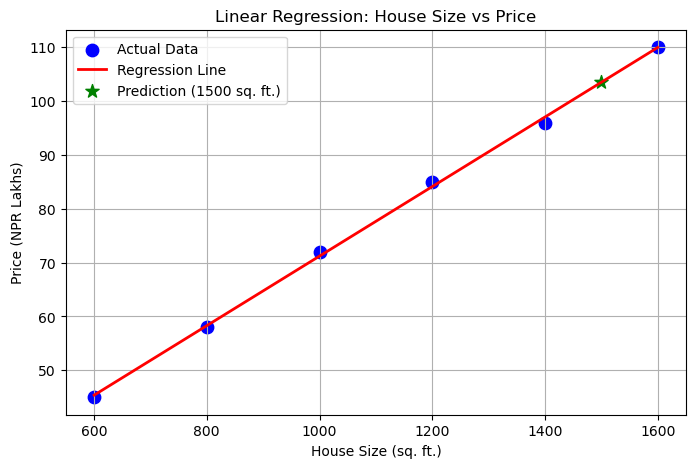

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, color='blue', s=80, label='Actual Data')

plt.plot(
    X,
    y_pred_sk,
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.scatter(
    1500,
    price_1500_sk,
    color='green',
    s=100,
    marker='*',
    label='Prediction (1500 sq. ft.)'
)

plt.xlabel("House Size (sq. ft.)")
plt.ylabel("Price (NPR Lakhs)")
plt.title("Linear Regression: House Size vs Price")
plt.grid(True)
plt.legend()

plt.show()

# Expected Observations
The Normal Equation and scikit-learn produce identical regression coefficients and prediction MSE, and R-squared score (up to numerical precision). This confirm 